# Task 1: Laying the Foundation for Analysis
### Brent Oil Price Change Point Analysis — Birhan Energies

**Objective:** Investigate the statistical properties of the Brent oil
price series — trend, stationarity, and volatility — to inform the
Bayesian change point modeling approach used in Task 2.

## 1. Data Loading

In [5]:
import sys
sys.path.append("../")  # so we can import from src/

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import importlib

importlib.reload(sys.modules["src.data_prep"])

from src.data_prep import load_price_data
from src.eda import run_adf_test, compute_rolling_stats

plt.rcParams["figure.figsize"] = (12, 5)

In [6]:
prices = load_price_data("../data/raw/BrentOilPrices.csv")

print(f"Rows: {prices.shape[0]}")
print(f"Date range: {prices.index.min().date()} to {prices.index.max().date()}")
prices.head()

Rows: 9011
Date range: 1987-05-20 to 2022-11-14


,Price
Date,
1987-05-20,18.63
1987-05-21,18.45
1987-05-22,18.55
1987-05-25,18.60
1987-05-26,18.63


## 2. Trend Analysis

We plot the raw price series to visually assess long-run trend
behavior, and overlay a 365-day rolling mean to smooth out short-term
noise and highlight the underlying trend more clearly.

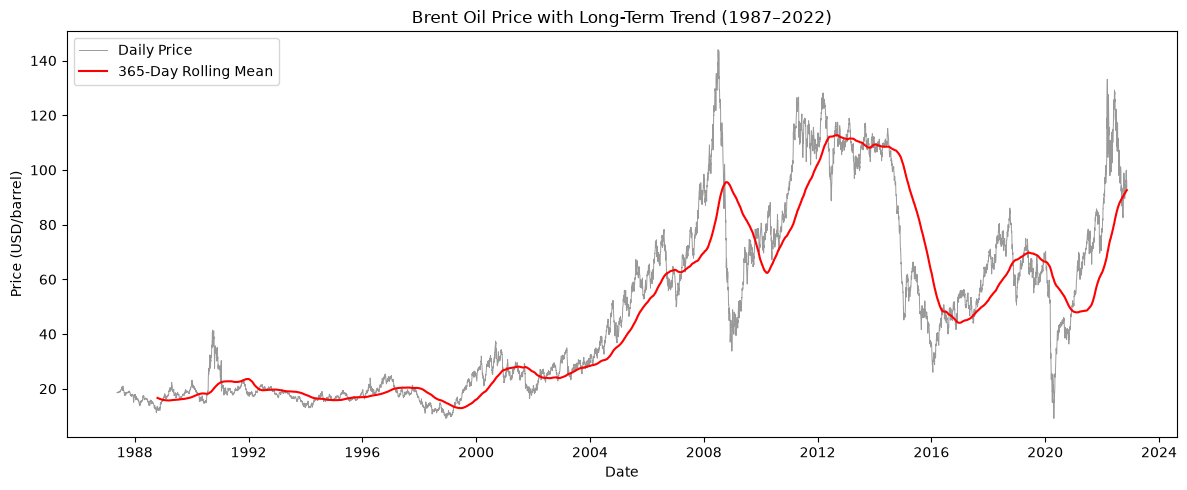

In [7]:
rolling_365 = compute_rolling_stats(prices["Price"], window=365)

fig, ax = plt.subplots()
ax.plot(prices.index, prices["Price"], color="black", alpha=0.4, linewidth=0.7, label="Daily Price")
ax.plot(rolling_365.index, rolling_365["rolling_mean"], color="red", linewidth=1.5, label="365-Day Rolling Mean")
ax.set_title("Brent Oil Price with Long-Term Trend (1987–2022)")
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD/barrel)")
ax.legend()
plt.tight_layout()
plt.show()

The rolling mean makes it clear the series does **not** hover around a
single fixed average. It drifts through multiple distinct eras: a long
stretch under $20-30/barrel through the 1990s, a steady climb through
the 2000s peaking near $140 in 2008, a crash, a rebound to roughly
$100-110, and further crashes post-2014 and in 2020. This non-constant
mean is the visual signature of a **non-stationary** series with trend.

## 3. Stationarity Testing

A model that assumes one fixed mean (or one fixed variance) for the
whole series only makes sense if the series is **stationary**. We test
this formally with the **Augmented Dickey-Fuller (ADF) test**:

- **H0 (null hypothesis):** the series is non-stationary (has a unit root)
- If p-value < 0.05 → reject H0 → series is stationary

In [8]:
adf_price = run_adf_test(prices["Price"], label="Raw Price")

--- ADF Test: Raw Price ---
ADF Statistic : -1.9939
p-value       : 0.2893
Critical Value (1%): -3.4311
Critical Value (5%): -2.8619
Critical Value (10%): -2.5669
Conclusion    : NON-STATIONARY (alpha = 0.05)



As expected from the trend plot above, the raw price series fails the
stationarity test. This has a direct consequence for Task 2: a Bayesian
change point model built on raw price levels would be misleading,
because "the mean price" isn't a stable, well-defined quantity across
35 years of data — it's constantly drifting.

The standard fix is to work with **log returns**
(`log(price_t) - log(price_{t-1})`) instead of price levels. Log
returns represent day-over-day percentage change rather than price
level, and are far more likely to be stationary. We check this here so
the finding can directly justify the modeling choice made in Task 2.

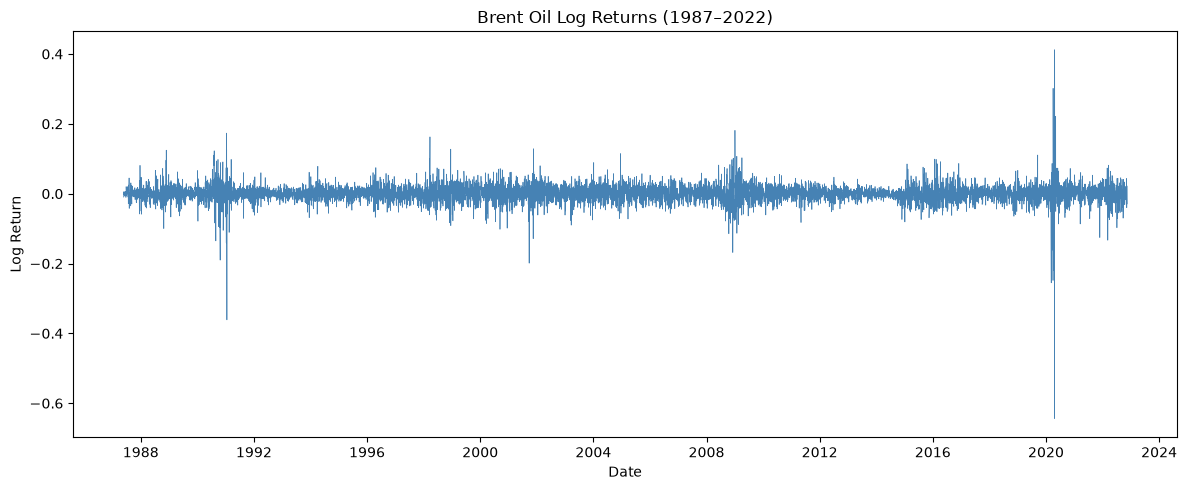

In [9]:
log_returns = np.log(prices["Price"]) - np.log(prices["Price"].shift(1))
log_returns = log_returns.dropna()

fig, ax = plt.subplots()
ax.plot(log_returns.index, log_returns, color="steelblue", linewidth=0.5)
ax.set_title("Brent Oil Log Returns (1987–2022)")
ax.set_xlabel("Date")
ax.set_ylabel("Log Return")
plt.tight_layout()
plt.show()

In [10]:
adf_log_returns = run_adf_test(log_returns, label="Log Returns")

--- ADF Test: Log Returns ---
ADF Statistic : -16.4271
p-value       : 0.0000
Critical Value (1%): -3.4311
Critical Value (5%): -2.8619
Critical Value (10%): -2.5669
Conclusion    : STATIONARY (alpha = 0.05)



Unlike the raw price series, log returns fluctuate around a stable
mean near zero with no visible long-term drift — and the ADF test
should confirm this statistically (very low p-value → reject H0 →
stationary). **This finding directly informs Task 2: the Bayesian
change point model will be built on log returns, not raw prices.**

## 4. Volatility Patterns

Beyond the mean, we also check whether the *spread* (variance) of the
series is stable over time, using a rolling standard deviation of log
returns.

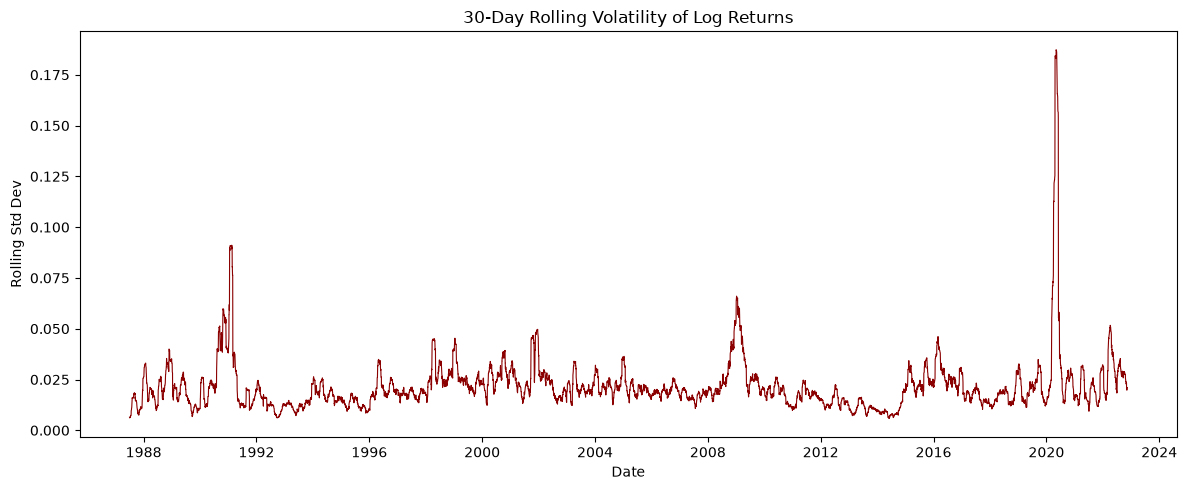

In [11]:
rolling_vol = compute_rolling_stats(log_returns, window=30)

fig, ax = plt.subplots()
ax.plot(rolling_vol.index, rolling_vol["rolling_std"], color="darkred", linewidth=0.8)
ax.set_title("30-Day Rolling Volatility of Log Returns")
ax.set_xlabel("Date")
ax.set_ylabel("Rolling Std Dev")
plt.tight_layout()
plt.show()

The rolling volatility plot shows clear **volatility clustering**:
calm, low-variance periods (e.g. much of the 1990s and mid-2000s) are
interrupted by sharp spikes in volatility around major shocks (e.g.
2008 financial crisis, 2014-2016 price collapse, 2020 COVID crash).
This tells us variance itself is not constant either — it's another
way the series is non-stationary, and a reminder that a structural
break can show up as a shift in *volatility*, not just a shift in
*mean*. For this project's core model (Task 2) we focus on detecting a
shift in mean log return, but this is worth flagging as a limitation:
a mean-only change point model won't necessarily flag a break that is
purely a volatility regime change.

## 5. Summary: How These Properties Inform Modeling Choices

| Property | Finding | Modeling Implication |
|---|---|---|
| Trend | Strong, multi-decade drift in raw price | Do not model raw price directly |
| Stationarity | Raw price non-stationary; log returns stationary | Use log returns as the model's input series |
| Volatility | Clear volatility clustering, non-constant variance | A mean-shift-only model may miss pure volatility regime changes (noted as a limitation / future work) |

These findings directly justify the Task 2 modeling decision to build
the Bayesian change point model on **log returns**, with a Normal
likelihood whose **mean** switches at an unknown change point `tau`.